# Introduction to Machine Learning - Exercise 9
Goal of the excercise is to learn how to use basic deep learning models in Scikit-learn and Keras.

![meme03](https://github.com/rasvob/EFREI-Introduction-to-Machine-Learning/blob/main/images/fml_11_meme_03.jpg?raw=true)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PowerTransformer
from sklearn.neural_network import MLPClassifier, MLPRegressor

# 📊 Deep learning introduction
* What types of neural networks (ANN) do you know?
    * For what types of data are these types the most useful? Why?

* What is the Multi-layer Perceptron (MLP)?
    * 🔎 What classic ML model is the closest to MLP by its function?
    * What is the difference between them?


## 📌 How does the ANN work in general?
* What does these terms mean?
    * Neuron
    * Input and weight
    * Activation function
        * Can ANN work without it?
    * Loss function
    * Optimizer

## Training and inference phase
* 🔎 How does the training phase work?
* And what about inference phase?
    * Which one is more computionaly intesive?

## 📒 Let's create an example of simple ANN using math formulas on blackboard

![img01](https://github.com/lubsar/EFREI-Introduction-to-Machine-Learning/blob/main/images/fml_11_ann_01.png?raw=true)

# 🔎 What is the difference between MLP and Deep learning (DL)?

![img02](https://github.com/lubsar/EFREI-Introduction-to-Machine-Learning/blob/main/images/fml_11_ann_02.png?raw=true)

# 🚀 Enough of theory, let's try it!

## Diabetes dataset
https://www.kaggle.com/datasets/saurabh00007/diabetescsv/data

### 🎯 Our goal is to build model able to classify if person has diabetes or not

In [ ]:
df = pd.read_csv('https://github.com/lubsar/EFREI-Introduction-to-Machine-Learning/raw/refs/heads/main/datasets/diabetes.csv')
df.head()

## Is each column numerical?

In [ ]:
df.dtypes

## Do we have any missing data?

In [ ]:
df.isna().sum()

## Is class distribution balanced?

In [ ]:
df.Outcome.value_counts()

# ⚡ What features are more important than others?
* Why?

In [ ]:
fig, axes = plt.subplots(1, df.shape[1]-1, figsize=(15, 6))

for i, col in enumerate(df.columns[:-1]):
    ax = axes.flatten()[i]
    sns.boxplot(data=df, y=col, x='Outcome', ax=ax, hue='Outcome')

fig.tight_layout()

## Now we can split the data into train/test set and proceed as usuall

In [ ]:
X, y = df.drop('Outcome', axis=1), df['Outcome']

In [ ]:
X.head()

In [ ]:
y.head()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

# 🚀 We will use the `MLPClassifier` model

https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html#sklearn.neural_network.MLPClassifier

* 💡 The sklearn ANN API is very basic, there are only a few parameters that are worth tuning
    * hidden_layer_sizes - the ANN hidden layers structure (tuple)
    * activation - activation function used in hidden layers
    * solver - optimizer
    * max_iter - number of epochs
    * batch_size - number of instances in one batch


## The pipeline is the same as with any other model
* We will define the model
* Fit it on training data
* Evaluate the performance

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(8,), activation='relu', solver='adam', max_iter=300, batch_size=32, random_state=13)

In [ ]:
clf.fit(X_train, y_train)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
f1_score(y_true=y_test, y_pred=y_pred)

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
ConfusionMatrixDisplay(cm, display_labels=clf.classes_).plot()

# 💡 You can see that it does not matter if you are using ML or DL models
## The key principles are still the same 🙂

![meme01](https://github.com/lubsar/EFREI-Introduction-to-Machine-Learning/blob/main/images/fml_11_meme_01.jpg?raw=true)

# 🔎 Can we improve the performace somehow?

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu', solver='adam', max_iter=300, batch_size=32, random_state=13)

In [ ]:
clf.fit(X_train, y_train)

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
f1_score(y_true=y_test, y_pred=y_pred)

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
ConfusionMatrixDisplay(cm, display_labels=clf.classes_).plot()

## ⚡ We've come to a conclusion that ANN and Linear regression is pretty similar in principle earlier
* Do you remember what is a general issue for optimization algorithms?
    * 💡 It is about a differences in the input features

* The model can be made much simpler with a preprocessing employed

In [ ]:
std_scaler = StandardScaler()
std_scaler.fit(X_train)
X_train_std = std_scaler.transform(X_train)
X_test_std = std_scaler.transform(X_test)

In [ ]:
clf = MLPClassifier(hidden_layer_sizes=(8,), activation='relu', solver='adam', max_iter=100, batch_size=32, random_state=13)

In [ ]:
clf.fit(X_train_std, y_train)

In [ ]:
y_pred = clf.predict(X_test_std)

In [ ]:
f1_score(y_true=y_test, y_pred=y_pred)

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
ConfusionMatrixDisplay(cm, display_labels=clf.classes_).plot()

# The Scikit-learn has not much more to offer unfortunately...

![meme02](https://github.com/lubsar/EFREI-Introduction-to-Machine-Learning/blob/main/images/fml_11_meme_02.jpg?raw=true)

# 🚀 ... and that's the the reason why there are other frameworks focused on ANN
* Do you know any?
    * Have you worked with some of them already?

## ⚡ We will learn the basics of the Tensorflow/Keras using a minimal example on the MNIST dataset.

In [ ]:
import tensorflow as tf
import tensorflow.keras as keras

tf.version.VERSION

# 💡 MNIST is the basic dataset with handwritten digits
* The data are in the form of 28x28 pixes with values 0-255
* The dataset consists of 60,000 training images and 10,000 testing images

In [ ]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print('Train data shape: ', x_train.shape)
print('Test data shape:  ', x_test.shape)

# Let's look on the data
* 🔎 Why are the values in 0-255 range?

In [ ]:
plt.figure()
plt.imshow(x_train[1])
plt.colorbar()
plt.grid(False)
plt.show()

# We can see that the numbers are already centered
* You won't see this feature in the real world images often 🙂
* Some of the images are quite easy to classify but on the other hand there is a lot of noise in the data as well.

## 🔎 What number is on image below? Is it 1 or 7?

In [ ]:
plt.figure()
plt.imshow(x_train[42])
plt.colorbar()
plt.grid(False)
plt.show()

# Lets normalize the values into the range \(0,1\) by dividing it 255.
* I guess that you already know why we do this preprocessing step 🙂

In [ ]:
x_train, x_test = x_train / 255.0, x_test / 255.0

# 📈 It's worth to make better visualization of the data to understand how complex they are
* You can see that "noisy" digits and different handwriting styles are common

In [ ]:
class_names = [str(x) for x in range(10)]

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

# 🌳 Before we dive in the deep learning territory, let's try to create some baseline model using a machine learning model so we can compare the approaches
* Are ML models capable of processing image data?
* 🔎 How to deal with a matrix input?

In [ ]:
alg = DecisionTreeClassifier(random_state=13)
alg.fit(x_train.reshape(-1, 28*28), y_train)

In [ ]:
y_pred = alg.predict(x_test.reshape(-1, 28*28))

In [ ]:
y_pred

In [ ]:
accuracy_score(y_true=y_test, y_pred=y_pred)

# We can see that we were able to create a classifier very easily
* However it is no secret, that DL models accuracy on MNIST can be >= 98% even with simple architecture
* Given the fact, our result is not very impresive 🙂

# 🚀 Let's design our first ANN in Keras
* Model is created using layers, many layers exists in the [layer submodule](https://www.tensorflow.org/api_docs/python/tf/keras/layers)
* Each layer uses a activation functions collected in the [module nn](https://www.tensorflow.org/api_docs/python/tf/nn)
* There are 2 ways of using the Keras API, **Sequential** and **Functional**
    * We will use the Sequential one

## 💡 Notice the last (output) layer
* Why do we have 10 neurons?
* Why do we use `softmax` activation?
    * Do you know any other common activation functions used in output layer?

In [ ]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),# Flatten module flatten the multidimension input into single vector 28x28 = 784 float numbers
    keras.layers.Dense(32, activation=tf.nn.relu), # standard dense-fully connected layer with the rectified lineaar function as an activation
    keras.layers.Dense(10, activation=tf.nn.softmax), # another fully-connected layer with softmax activation function
])

model.summary() # prints the summary of the model

# 🔎 What is the meaning of the `Total params` number?

# 📌Each model need to be compiled to be able to fit to the data and predict the labels
* There are 3 important parameters we need to set

### 1 - Optimizer
* There are many optimizers available, you can experiment with different algorithms, most of them are based on gradient descent algorithm

### 2 - Loss function
* Training of the ANN is about weights optimization
* We need to some formula that says us if the optimization process is making the ANN better or not

* **The choice of a loss function depends on tha task and network architecture. Below are the most common loss functions mentioned.**
    * Mean Squared Error
       * A classical measure to be used in regression
    * Binary Cross-Entropy
       * Predict the class from the set {0,1}
       * Requires a sigmoid activation function
    * Categorical Cross-Entropy
       * Default for mutli-class classification problems
       * Requires the softmax function on output layer to compute probability of each label
       * Labels have to be one-hot-encoded
    * Sparse Categorical Cross-Entropy
       * The same as above, but the labels are not encoded

### 3 - Metric
* Used metrics for the model prediction accuracy evaluation are the same as in the ML area, i.e. accuracy, f1-score, recall, etc.
* The choice depends on the task and the labels distribution.

# ⚡ We can compile the model now
* We will use the accuracy metric
* Why do we use `SparseCategoricalCrossentropy`?
    * What is `from_logits` parameter?

* `SparseCategoricalCrossentropy` -> We expect labels to be provided as integers

* The output of the Dense layer will either return:
    * **probabilities**: The output is passed through a SoftMax function which normalizes the output into a set of probabilities over N neurons, that all add up to 1
    * **logits**: Raw output of N activations - no normalization by SoftMax applied

* Your loss function has to be informed as to whether it should expect a normalized distribution (output passed through a SoftMax function) or logits
    * 💡 If your output layer has a 'softmax' activation, `from_logits` should be `False`
    * 💡 If your output layer doesn't have a 'softmax' activation, `from_logits` should be `True`

In [ ]:
model.compile(optimizer='adam',
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics = ['accuracy'],
    )

# Model visualization
* The model may be printed into image

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

# ⚡ Now we can fit the model to the input data
* The `fit()` method fit the model to the data
    * The parameters are *data* and *labels* from the train set and number of *epoch* to be trained
* The `validation_split` parameter is also very common
    * What does the parameter do?
    * 🔎 What is the validation set?
    * How is it different from the test set?

# Define the callbacks
* 💡 Always use ModelCheckpoint callback so you overcome the possible overfitting in the last few epochs!
- **The best weights are determined using the validation loss value**

In [ ]:
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

# Fit the model

In [ ]:
history = model.fit(x_train, y_train, validation_split=0.2, epochs=15, callbacks=[model_checkpoint_callback], batch_size=32)

# Let's take a look at the accuracy and loss function values of train and validation set
* What can you see in the plot?
* Is OK that loss is getting lower and accuracy higher?
    * 🔎 Can the loss function value go higher?
* What if the training set loss is getting lower, but validation set loss higher?
    * 🔎 How do we call this situation?

In [ ]:
plt.figure()
for key in history.history.keys():
    plt.plot(history.epoch, history.history[key], label=key)
plt.legend()
plt.tight_layout()

# 💡 Beware that the best weights needs to be loaded after the training is finished!
* **Otherwise you use the weights from the last epoch!**

In [ ]:
model.load_weights("best.weights.h5")

# We can use `evaluate()` function for obtaining the accuracy using the test set

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print('Test accuracy: ', test_acc)

# 📒 Can we obtain the labels and use it for our own evaluation without Keras? Sure!

## We will obtain the raw softmax outputs first
* What is the range of the vector values?
* Do they sum-up to some number?

In [ ]:
y_pred_proba = model.predict(x_test)

In [ ]:
y_pred_proba[0]

## The numbers are hard to read, let's rather create barplot 🙂

In [ ]:
sns.barplot(x=np.arange(0, len(y_pred_proba[0])), y=y_pred_proba[0])

In [ ]:
np.sum(y_pred_proba[0])

## We need to extract the index of the highest probability to get the label
* 🔎 What will be the output in our case?

In [ ]:
np.argmax(y_pred_proba[0])

## And finally we can use the `argmax` on the whole output matrix...

In [ ]:
y_pred = np.argmax(y_pred_proba, axis=1)

In [ ]:
y_pred

## ... and compute the `accuracy_score` ✌
* Did we beat the ML baseline? 🙂

In [ ]:
accuracy_score(y_true=y_test, y_pred=y_pred)

# ✅ Task
* Take a look at the Keras documentation
    * https://keras.io/guides/sequential_model/
    * https://keras.io/api/models/model_training_apis/
    * https://keras.io/api/layers/activations/
* Try to modify the architecture of the neural network
  * Add or remove hidden `Dense` layers
  * Change `activation` function of the hidden layers
  * 💡 Is accuracy better or worse with your modification?
* Try to change the `batch_size` in the `fit` method
  * Test values `1`, `8`, `16`, `32`, `64`
  * 💡 How was the training time and accuracy changed with different `batch_size` values?

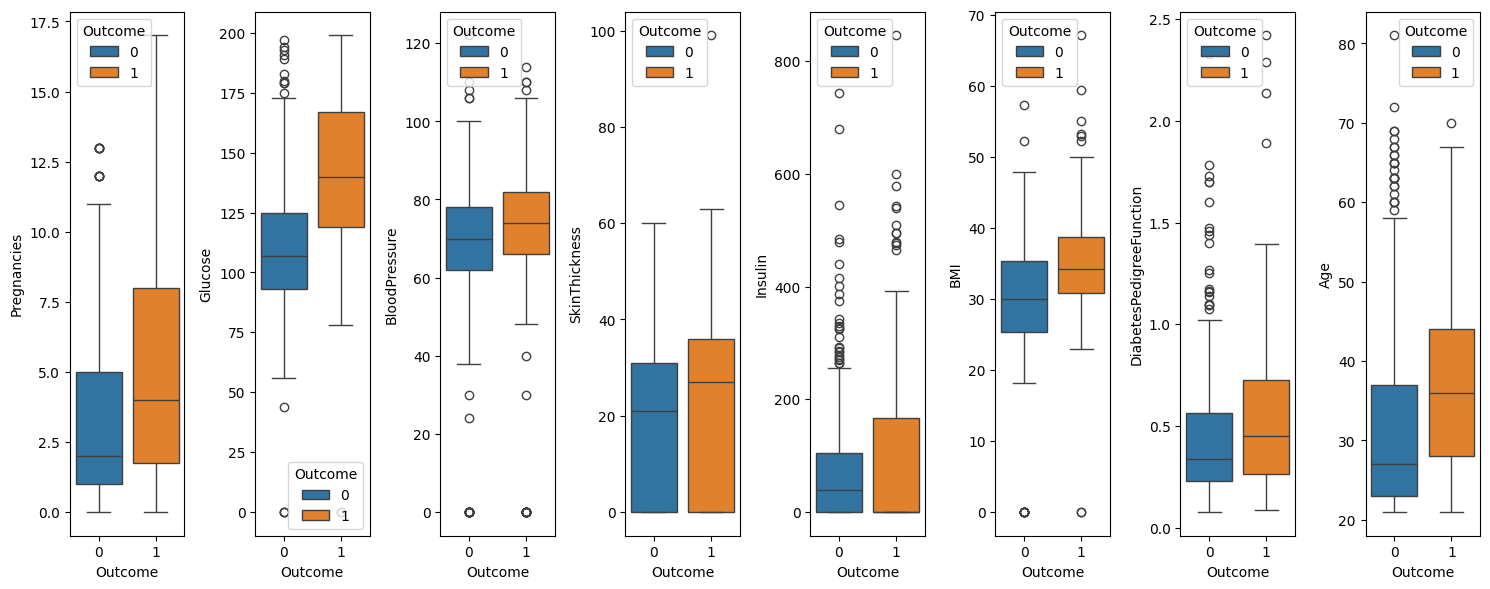

Train shapes: X=(614, 8), y=(614,)
Test shapes: X=(154, 8), y=(154,)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


F1 Score (basic): 0.5053


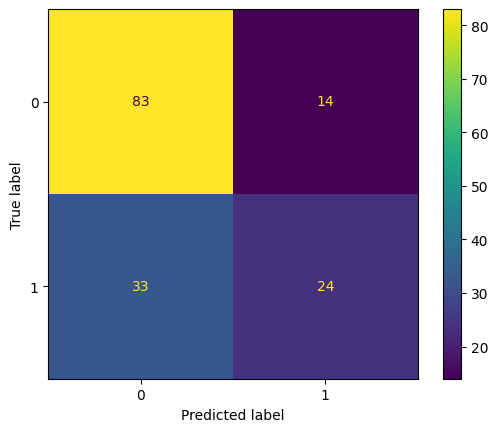

F1 Score (larger arch): 0.6565


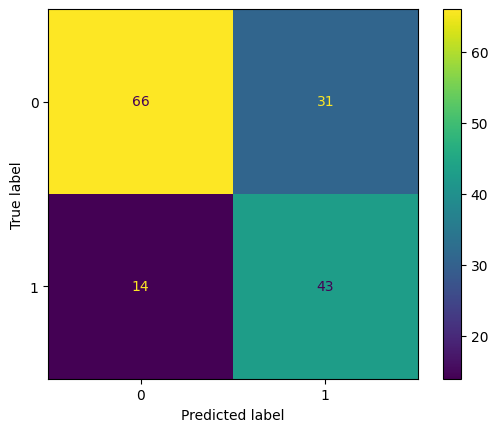

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


F1 Score (with standardization): 0.6263


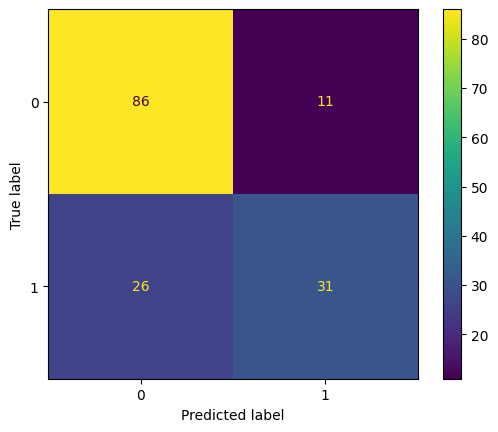

TensorFlow version: 2.19.0
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train data shape: (60000, 28, 28)
Test data shape:  (10000, 28, 28)


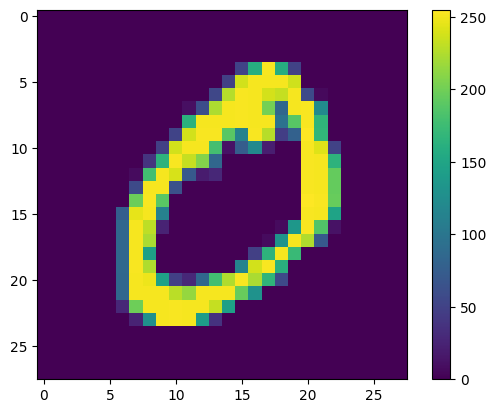

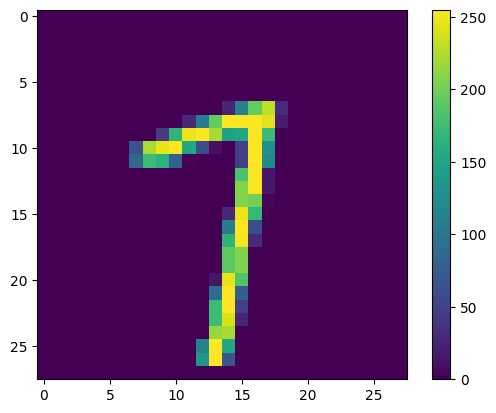

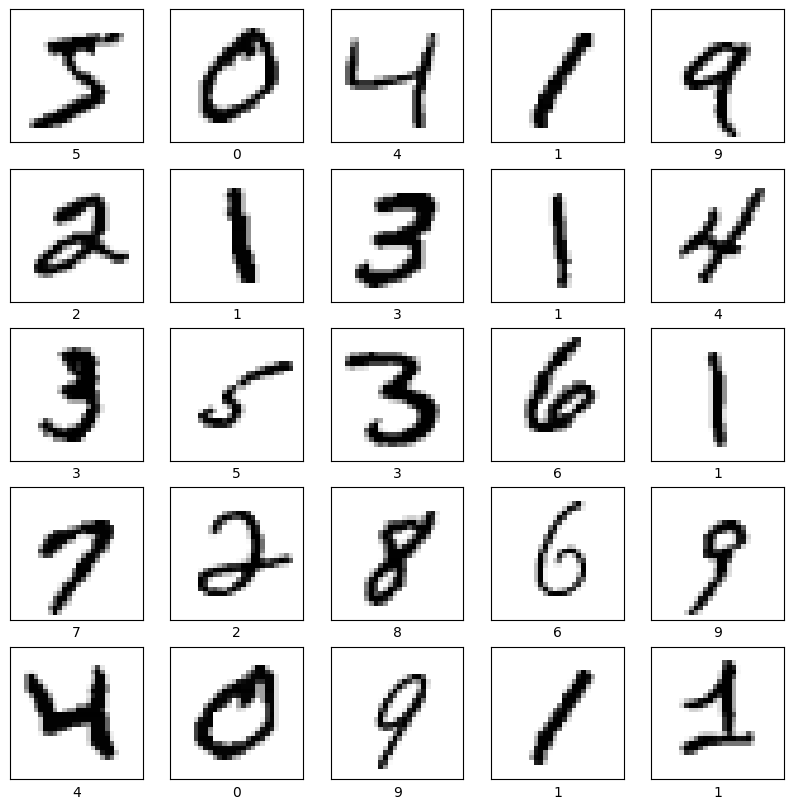

In [ ]:
# =========== IMPORTS ===========
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PowerTransformer
from sklearn.neural_network import MLPClassifier, MLPRegressor

# =========== DIABETES DATASET ===========

# Load the dataset
df = pd.read_csv('https://github.com/lubsar/EFREI-Introduction-to-Machine-Learning/raw/refs/heads/main/datasets/diabetes.csv')
df.head()

# Check data types
df.dtypes

# Check for missing data
df.isna().sum()

# Check class distribution
df.Outcome.value_counts()

# Visualize features by outcome
fig, axes = plt.subplots(1, df.shape[1]-1, figsize=(15, 6))

for i, col in enumerate(df.columns[:-1]):
    ax = axes.flatten()[i]
    sns.boxplot(data=df, y=col, x='Outcome', ax=ax, hue='Outcome')

fig.tight_layout()
plt.show()

# Split data
X, y = df.drop('Outcome', axis=1), df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=13)

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}")

# =========== MLP CLASSIFIER (BASIC) ===========

# Basic MLP without preprocessing
clf = MLPClassifier(hidden_layer_sizes=(8,), activation='relu', solver='adam', max_iter=300, batch_size=32, random_state=13)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"F1 Score (basic): {f1_score(y_true=y_test, y_pred=y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
ConfusionMatrixDisplay(cm, display_labels=clf.classes_).plot()
plt.show()

# =========== MLP CLASSIFIER (LARGER ARCHITECTURE) ===========

clf = MLPClassifier(hidden_layer_sizes=(64,32), activation='relu', solver='adam', max_iter=300, batch_size=32, random_state=13)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(f"F1 Score (larger arch): {f1_score(y_true=y_test, y_pred=y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
ConfusionMatrixDisplay(cm, display_labels=clf.classes_).plot()
plt.show()

# =========== MLP WITH STANDARDIZATION ===========

# Standardize features
std_scaler = StandardScaler()
std_scaler.fit(X_train)
X_train_std = std_scaler.transform(X_train)
X_test_std = std_scaler.transform(X_test)

clf = MLPClassifier(hidden_layer_sizes=(8,), activation='relu', solver='adam', max_iter=100, batch_size=32, random_state=13)
clf.fit(X_train_std, y_train)

y_pred = clf.predict(X_test_std)
print(f"F1 Score (with standardization): {f1_score(y_true=y_test, y_pred=y_pred):.4f}")

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
ConfusionMatrixDisplay(cm, display_labels=clf.classes_).plot()
plt.show()

# =========== TENSORFLOW/KERAS MNIST EXAMPLE ===========

import tensorflow as tf
import tensorflow.keras as keras

print(f"TensorFlow version: {tf.version.VERSION}")

# Load MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f'Train data shape: {x_train.shape}')
print(f'Test data shape:  {x_test.shape}')

# Visualize first image
plt.figure()
plt.imshow(x_train[1])
plt.colorbar()
plt.grid(False)
plt.show()

# Visualize ambiguous image
plt.figure()
plt.imshow(x_train[42])
plt.colorbar()
plt.grid(False)
plt.show()

# Normalize pixel values to range [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Visualize multiple examples
class_names = [str(x) for x in range(10)]

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_train[i]])
plt.show()

# =========== BASELINE WITH DECISION TREE ===========

# Reshape images from 28x28 to 784 pixels
alg = DecisionTreeClassifier(random_state=13)
alg.fit(x_train.reshape(-1, 28*28), y_train)

y_pred = alg.predict(x_test.reshape(-1, 28*28))
print(f"Decision Tree Accuracy: {accuracy_score(y_true=y_test, y_pred=y_pred):.4f}")

# =========== KERAS NEURAL NETWORK ===========

# Build the model
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  # Flatten 28x28 to 784
    keras.layers.Dense(32, activation='relu'),   # Hidden layer with 32 neurons
    keras.layers.Dense(10, activation='softmax') # Output layer with 10 neurons
])

model.summary()

# Compile the model
model.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Visualize model architecture
keras.utils.plot_model(model, show_shapes=True)

# Set up ModelCheckpoint callback
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='best.weights.h5',
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True
)

# Train the model
history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=15,
    callbacks=[model_checkpoint_callback],
    batch_size=32,
    verbose=1
)

# Plot training history
plt.figure()
for key in history.history.keys():
    plt.plot(history.epoch, history.history[key], label=key)
plt.legend()
plt.xlabel('Epoch')
plt.tight_layout()
plt.show()

# Load best weights
model.load_weights("best.weights.h5")

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')

# Make predictions
y_pred_proba = model.predict(x_test)

# Visualize predictions for first test sample
sns.barplot(x=np.arange(0, len(y_pred_proba[0])), y=y_pred_proba[0])
plt.title('Class probabilities for first test sample')
plt.xlabel('Digit')
plt.ylabel('Probability')
plt.show()

print(f"Sum of probabilities: {np.sum(y_pred_proba[0]):.4f}")
print(f"Predicted digit for first sample: {np.argmax(y_pred_proba[0])}")

# Get all predictions
y_pred = np.argmax(y_pred_proba, axis=1)
print(f"Keras Model Accuracy: {accuracy_score(y_true=y_test, y_pred=y_pred):.4f}")

# =========== EXERCISE TASKS ===========

# TASK 1: Experiment with different architectures
def create_and_train_model(arch_config, batch_size=32):
    """Helper function to create and train models with different architectures"""

    # Create model based on architecture configuration
    layers = [keras.layers.Flatten(input_shape=(28, 28))]

    for units, activation in arch_config['hidden_layers']:
        layers.append(keras.layers.Dense(units, activation=activation))

    layers.append(keras.layers.Dense(10, activation='softmax'))

    model = keras.Sequential(layers)

    # Compile
    model.compile(
        optimizer='adam',
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    # Train
    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=10,  # Reduced for faster experimentation
        batch_size=batch_size,
        verbose=0
    )

    # Evaluate
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    return model, history, test_acc

# Example architectures to try
architectures = [
    {
        'name': 'Original (32 relu)',
        'hidden_layers': [(32, 'relu')]
    },
    {
        'name': 'Deeper (64 relu, 32 relu)',
        'hidden_layers': [(64, 'relu'), (32, 'relu')]
    },
    {
        'name': 'Wider (128 relu)',
        'hidden_layers': [(128, 'relu')]
    },
    {
        'name': 'Sigmoid activation',
        'hidden_layers': [(32, 'sigmoid')]
    },
    {
        'name': 'Tanh activation',
        'hidden_layers': [(32, 'tanh')]
    },
    {
        'name': 'Very deep (128, 64, 32)',
        'hidden_layers': [(128, 'relu'), (64, 'relu'), (32, 'relu')]
    }
]

print("\n=== Experimenting with Different Architectures ===")
for arch in architectures:
    _, _, test_acc = create_and_train_model(arch)
    print(f"{arch['name']}: Test Accuracy = {test_acc:.4f}")

# TASK 2: Experiment with different batch sizes
batch_sizes = [1, 8, 16, 32, 64]
training_times = []
accuracies = []

print("\n=== Experimenting with Different Batch Sizes ===")
for batch_size in batch_sizes:
    print(f"\nTraining with batch_size = {batch_size}")

    # Create simple model
    model = keras.Sequential([
        keras.layers.Flatten(input_shape=(28, 28)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )

    # Time the training
    import time
    start_time = time.time()

    history = model.fit(
        x_train,
        y_train,
        validation_split=0.2,
        epochs=5,  # Reduced for faster experimentation
        batch_size=batch_size,
        verbose=0
    )

    training_time = time.time() - start_time
    training_times.append(training_time)

    # Evaluate
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    accuracies.append(test_acc)

    print(f"  Training time: {training_time:.2f} seconds")
    print(f"  Test accuracy: {test_acc:.4f}")

# Plot batch size results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(batch_sizes, training_times, 'bo-')
ax1.set_xlabel('Batch Size')
ax1.set_ylabel('Training Time (seconds)')
ax1.set_title('Training Time vs Batch Size')
ax1.grid(True)

ax2.plot(batch_sizes, accuracies, 'ro-')
ax2.set_xlabel('Batch Size')
ax2.set_ylabel('Test Accuracy')
ax2.set_title('Accuracy vs Batch Size')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Summary of findings
print("\n=== SUMMARY ===")
print("1. Architecture experiments show that:")
print("   - ReLU activation generally works well")
print("   - Adding more layers can help but may cause overfitting")
print("   - Too simple architectures may underfit")
print("\n2. Batch size experiments show that:")
for i, bs in enumerate(batch_sizes):
    print(f"   Batch size {bs}: Time={training_times[i]:.2f}s, Accuracy={accuracies[i]:.4f}")
print("\n   Observations:")
print("   - Smaller batch sizes take longer to train")
print("   - Very small batch sizes (1) can be noisy and less stable")
print("   - Moderate batch sizes (16-32) often provide good balance")